In [76]:
from pyscarcopula.src.N2.N2Copula import N2Copula
from pyscarcopula.src.N7.N7Copula import N7Copula
from pyscarcopula.src.N8.N8Copula import N8Copula

from pyscarcopula.src.N22.N22Copula import N22Copula
from pyscarcopula.src.N21.N21Copula import N21Copula
from pyscarcopula.src.N20.N20Copula import N20Copula

from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopula.src.GenestGhoudi.GenestGhoudiCopula  import GenestGhoudiCopula
from pyscarcopula.src.GumbelBarnett.GumbelBarnettCopula  import GumbelBarnettCopula
from pyscarcopula.src.Frank.FrankCopula  import FrankCopula
from pyscarcopula.src.Joe.JoeCopula  import JoeCopula
from pyscarcopula.src.AliMikhailHaq.AliMikhailHaqCopula  import AliMikhailHaqCopula

from pyscarcopula.metrics.risk_metrics import risk_metrics
from pyscarcopula.aux_functions.funcs import jit_pobs, pobs
from pyscarcopula.metrics.marginals import get_marginals_params_params, get_rvs
from scipy.stats import chi2

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib.ticker as plticker

from numba import jit, prange, njit
from scipy.optimize import minimize, Bounds

from tqdm import tqdm


In [52]:
'''Read data and transform returns to pseudo observations'''
returns_data1 = pd.read_csv(r"data/test_returns_data_for_eis.csv", index_col=0) # Data from MOEX for tickers: AFKS, ROSN, SBER, YNDX. 
                                                                                # Data starts from 01.01.2020 with 30-minutes interval  
returns_data2 = pd.read_csv(r"data/dj.csv", sep=';') # Daily data of indexies DowJones и NASDAQ. 
                                                     # Data starts from 01.01.1990

moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = GumbelCopula(count_instruments)

In [64]:
fit_params = copula.fit(pobs_data)
fit_params

       message: Optimization terminated successfully
       success: True
        status: 0
           fun: 519.1275407953397
             x: [ 5.148e-01]
           nit: 3
           jac: [ 1.062e-01]
          nfev: 10
          njev: 3
          name: Gumbel copula
        method: MLE
 x_transformed: [ 1.265e+00]

In [106]:
T = len(moex_returns)
mp = get_marginals_params_params(moex_returns, T, 'normal')[-1]
rvs = get_rvs(mp, 10000000,'normal')
weight = np.ones(count_instruments) / count_instruments
loss = 1 - np.exp(rvs) @ weight
copula_pdf_data = copula.np_pdf()(pobs.T, fit_params.x_transformed)

calc marginals_params


In [107]:
np.mean(copula_pdf_data)

0.9464861727425549

In [101]:
@jit(nopython=True, parallel = True, cache = True)
def F_cvar_q(q, gamma, loss, copula_pdf_data):
    n = len(copula_pdf_data)
    mean = 0.0
    for k in prange(0, n):
        mean += copula_pdf_data[k] * np.maximum(loss[k] - q[0], 0.0)
    mean = mean / n
    F = q[0] + 1 / (1 - gamma) * mean
    return F

In [112]:
T = len(moex_returns)
window_len = 100
iters = T - window_len + 1
mp = get_marginals_params_params(moex_returns, window_len, 'normal')
var_data2 = np.zeros(T)
cvar_data2 = np.zeros(T)
for k in tqdm(range(0, iters)):
    pobs = jit_pobs(moex_returns[k:k+window_len])
    fit_params = copula.fit(pobs)

    idx = k + window_len - 1
    rvs = get_rvs(mp[idx], 1000000,'normal')
    pobs = jit_pobs(rvs)
    copula_pdf_data = copula.np_pdf()(pobs.T, fit_params.x_transformed)
    weight = np.ones(count_instruments) / count_instruments
    loss =  1 - np.exp(rvs) @ weight
    gamma = 0.95
    x0 = 0
    min_result = minimize(F_cvar_q, x0 = x0,
                                    args=(gamma, loss, copula_pdf_data),
                                    method='SLSQP',
                                    tol = 1e-7)
    var_data2[idx] = min_result.x[0]
    cvar_data2[idx] = min_result.fun
    #print(min_result.x)

calc marginals_params


100%|██████████| 501/501 [12:17<00:00,  1.47s/it]


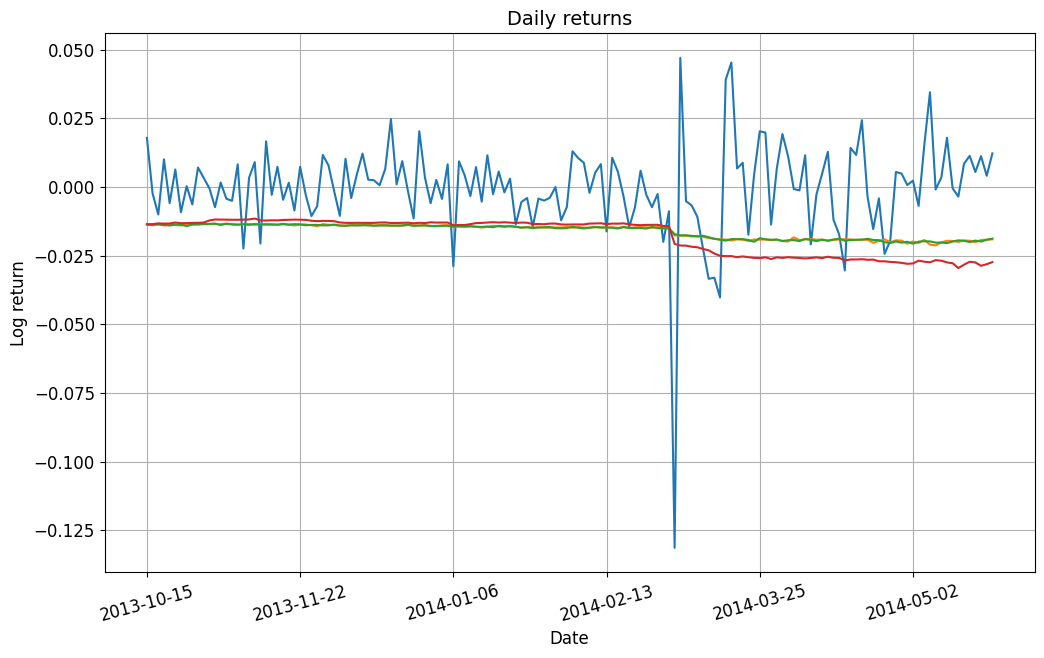

In [119]:
n = 1
m = 1
fig,ax = plt.subplots(n,m,figsize=(12,7))
i1 = 450
i2 = 600
loc = plticker.MultipleLocator(base=27.0)

#ax.plot(((np.exp(moex_returns_pd) - 1) * pd_weight_data).sum(axis=1)[i1:i2], label = 'Portfolio log return')
ax.plot(((np.exp(moex_returns_pd) - 1) * weight).sum(axis=1)[i1:i2], label = 'Portfolio log return')

# ax.plot(pd_var_70[i1:i2], label = f'{method} $10^6$ CVaR {gamma[0] * 100}%')
# ax.plot(pd_var_80[i1:i2], label = f'{method} $10^6$ CVaR {gamma[1] * 100}%')
# ax.plot(pd_var_90[i1:i2], label = f'{method} $10^6$ CVaR {gamma[2] * 100}%')
ax.plot(var_data[i1:i2], label = f'modified $10^6$ CVaR {gamma * 100}%')
ax.plot(-var_data0[i1:i2], label = f'$10^6$ CVaR {gamma * 100}%')
ax.plot(-var_data2[i1:i2], label = f'wl = 100 $10^6$ CVaR {gamma * 100}%')

# ax.plot(pd_var_97[i1:i2], label = f'{method} $10^6$ CVaR {gamma[4] * 100}%')
# ax.plot(pd_var_99[i1:i2], label = f'{method} $10^6$ CVaR {gamma[5] * 100}%')
# ax.plot(pd_var_999[i1:i2], label = f'{method} $10^6$ CVaR {gamma[6] * 100}%')

ax.set_title(f'Daily returns', fontsize = 14)

ax.xaxis.set_major_locator(loc)
ax.set_xlabel('Date', fontsize = 12, loc = 'center')
ax.set_ylabel('Log return', fontsize = 12, loc = 'center')
ax.tick_params(axis='x', labelrotation = 15, labelsize = 12)
ax.tick_params(axis='y', labelsize = 12)
ax.grid(True)
#ax.legend(fontsize=12, loc = 'upper right')


In [57]:
x0 = 0
min_result = minimize(F_cvar_q, x0 = x0,
                                args=(gamma, loss, copula_pdf_data),
                                method='SLSQP',
                                tol = 1e-7)
min_result

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.2561716882932942
       x: [-3.146e-01]
     nit: 9
     jac: [-5.286e-05]
    nfev: 24
    njev: 9

In [38]:
F_cvar_q(np.array([-5.31]), gamma, loss, copula_pdf_data)

84.56373990235669